In [1]:
# Import necessary libraries
import pandas as pd
from collections import defaultdict
import geopandas as gpd
from shapely import wkt
import shapely

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import pickle
%matplotlib inline
import datetime
import time
import numpy as np
import xml.etree.ElementTree as ET 
import matsim

import utm
from shapely.geometry import Polygon, Point
import gzip
from matplotlib import cm

import matplotlib.ticker as ticker
import matplotlib.font_manager as font_manager
import matplotlib as mpl
from matplotlib.lines import Line2D
from tqdm import tqdm
from matplotlib.colors import LinearSegmentedColormap


In [2]:
import geopandas as gpd

# --- Grid einlesen ---
grid_path = "input/final_grid_250.shp"
grid_gdf = gpd.read_file(grid_path)
grid_gdf = grid_gdf.reset_index().rename(columns={"index": "grid_index"})

# --- Demand-Shape einlesen (Dienstag) ---
demand_path = "input/hagrid_parcel_demand_2025-05-13_(Tuesday).shp"
parcel_input_demand_tuesday = gpd.read_file(demand_path)

# CRS prüfen
assert grid_gdf.crs.to_epsg() == 25832, "Grid CRS ist nicht EPSG:25832"
assert parcel_input_demand_tuesday.crs.to_epsg() == 25832, "Demand CRS ist nicht EPSG:25832"



KeyboardInterrupt: 

In [7]:

# Input folder path
folder = "../parcel-demand-estimation/input/"

# File names
dhl_streets_file = "dhl2streets_2021.shp"                   # DHL street segments with daily volume

# -------------------------------------------------------------------------------
# 2. Load DHL street segments (Shapefile), reproject and rename daily volume column
# -------------------------------------------------------------------------------
dhl_streets_gdf = gpd.read_file(folder + dhl_streets_file, encoding='UTF-8')
dhl_streets_gdf = dhl_streets_gdf.to_crs("EPSG:25832")
dhl_streets_gdf = dhl_streets_gdf.rename(columns={'tagesschni': 'dhl_tag'})  # 'dhl_tag' = daily DHL volume

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Dummy-Daten laden als Beispielstruktur (echte Daten wären in Geopandas, hier abstrahiert)
# Annahme: Beide DataFrames sind bereits in pandas geladen und heißen entsprechend:
# dhl_streets_gdf und parcel_input_demand_tuesday

# Aggregation in parcel_input_demand_tuesday: Summe DHL b2b + b2c je Straßenname
demand_agg = parcel_input_demand_tuesday.groupby("name")[["dhl_b2b", "dhl_b2c"]].sum()
demand_agg["total_dhl"] = demand_agg["dhl_b2b"] + demand_agg["dhl_b2c"]

# Aggregation in dhl_streets_gdf: Summe dhl_tag je Straßenname
tag_agg = dhl_streets_gdf.groupby("name")[["dhl_tag"]].sum()

# Zusammenführen über 'name'
merged = demand_agg.merge(tag_agg, on="name")
merged = merged[merged["dhl_tag"] <1000 ]  # F




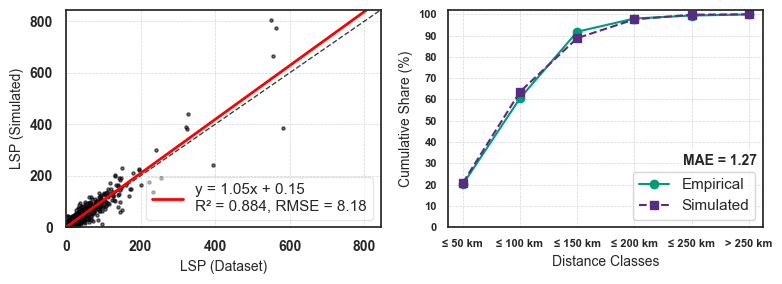

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib.font_manager import FontProperties

# === Daten für kumulativen Plot ===
labels = ["≤ 50 km", "≤ 100 km", "≤ 150 km", "≤ 200 km", "≤ 250 km", "> 250 km"]
x_dist = np.arange(len(labels))

empirical = np.array([20.1, 40.5, 31.2, 6.2, 1.4, 0.5])
simulated = np.array([20.8, 42.8, 25.2, 8.8, 2.2, 0.2])

empirical_cumsum = np.cumsum(empirical)
simulated_cumsum = np.cumsum(simulated)

# === Daten für Regressionsplot ===
X = merged["dhl_tag"].values.reshape(-1, 1)
y = merged["total_dhl"].values

reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)

slope = reg.coef_[0]
intercept = reg.intercept_
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

# === Gemeinsamer Plot ===
fig, axs = plt.subplots(1, 2, figsize=(8, 3))

# --- Plot 1: Scatter mit Regressionslinie ---
axs[0].scatter(X, y, alpha=0.6, edgecolor="k", s=5)

# Diagonale und Achsenbegrenzung
lims = [0, max(np.max(X), np.max(y)) * 1.05]
axs[0].plot(lims, lims, 'k--', alpha=0.75, linewidth=1)
axs[0].set_xlim(lims)
axs[0].set_ylim(lims)

# Regressionslinie über gesamten Plotbereich
x_fit = np.linspace(*lims, 200)
y_fit = reg.predict(x_fit.reshape(-1, 1))
label = f"y = {slope:.2f}x + {intercept:.2f}\nR² = {r2:.3f}, RMSE = {rmse:.2f}"

axs[0].plot(x_fit, y_fit, color="red", linewidth=2,
            label = label)

axs[0].set_xlabel("LSP (Dataset)", size=10)
axs[0].set_ylabel("LSP (Simulated)", size=10)
axs[0].grid(True, linestyle="--", linewidth=0.5, alpha=0.8)

legend_font = FontProperties(weight='normal', size=10)
axs[0].legend(loc="upper left", prop=legend_font)

axs[0].tick_params(labelsize=10)

# --- Plot 2: Kumulative Verteilung ---
axs[1].plot(x_dist, empirical_cumsum, marker="o", linestyle="-", label="Empirical", color="#009B77", linewidth=1.5, alpha = 1)
axs[1].plot(x_dist, simulated_cumsum, marker="s", linestyle="--", label="Simulated", color="#582C83", linewidth=1.5, alpha = 1)
axs[1].set_xticks(x_dist)
axs[1].set_xticklabels(labels, size = 8)
axs[1].set_yticks(np.arange(0, 110, 10))
axs[1].tick_params(axis='both', which='both', direction='out', length=5, width=1)
axs[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.8)
axs[1].set_ylabel("Cumulative Share (%)", size = 10)
axs[1].set_xlabel("Distance Classes", size = 10)
axs[1].set_ylim(0, 102)
axs[1].legend(loc="upper left", fontsize=10)

# MAE-Textbox
mae = np.mean(np.abs(simulated_cumsum - empirical_cumsum))
textstr = f"MAE = {mae:.2f}"
props = dict(boxstyle="round", facecolor="white", alpha=0.8)
axs[1].text(0.98, 0.275, textstr, transform=axs[1].transAxes,
            fontsize=10, verticalalignment='bottom', horizontalalignment='right', bbox=props)

axs[0].legend(loc="lower right", fontsize=10, prop={'weight': 'normal'}, framealpha=0.5)
axs[1].legend(loc="lower right", fontsize=10, prop={'weight': 'normal'}, framealpha=0.8)

plt.tight_layout()
plt.savefig("trb_combined_validation_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [102]:
import pandas as pd
import os

# Basisverzeichnis lokal anpassen
base_dir = r"U:\HAGRID"
basecases = [f"basecase_{day}052025" for day in range(12, 18)]
results = []

for case in basecases:
    file_path = os.path.join(base_dir, case, "analysis", "freight", "TimeDistance_perVehicle.tsv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep="\t")
        df["date"] = case
        results.append(df)
    else:
        print(f"❌ Datei nicht gefunden: {file_path}")

# Zusammenführen
if results:
    combined_df = pd.concat(results, ignore_index=True)
else:
    combined_df = pd.DataFrame()


In [103]:
from collections import defaultdict

# Nur Medium und Large Vans (Typ-ID enthält 'size_m' oder 'size_l')
valid_keywords = ['size_m', 'size_l']
filtered_combined = combined_df[combined_df['vehicleTypeId'].str.contains('|'.join(valid_keywords))]

# Aggregieren nach Tag
daily_summary = (
    filtered_combined.groupby('date')
    .agg(
        num_vehicles=('vehicleId', 'nunique'),
        total_distance_km=('travelDistance[m]', lambda x: round(x.sum() / 1000, 2))
    )
    .reset_index()
)

print(daily_summary)


                date  num_vehicles  total_distance_km
0  basecase_12052025          1653          148634.21
1  basecase_13052025          1744          155554.16
2  basecase_14052025          1912          165243.94
3  basecase_15052025          1866          169079.74
4  basecase_16052025          1602          154402.25
5  basecase_17052025          1308          131780.05


In [119]:
import geopandas as gpd
import pandas as pd
import os
from glob import glob

# Pfad zu den shapefiles (anpassen falls nötig)
shapefile_dir = r"U:\HAGRID\shapes"  # z. B. Speicherort der .shp-Dateien
shapefiles = sorted(glob(os.path.join(shapefile_dir, "hagrid_parcel_demand_2025-05-*.shp")))

# LSP-Spalten
lsp_columns = [
    'ama_b2b', 'ama_b2c',
    'dhl_b2b', 'dhl_b2c',
    'dpd_b2b', 'dpd_b2c',
    'gls_b2b', 'gls_b2c',
    'her_b2b', 'her_b2c',
    'ups_b2b', 'ups_b2c',
    'fxt_b2b', 'fxt_b2c'
]

results = []

# Durchlaufe alle Shapefiles
for shp in shapefiles:
    gdf = gpd.read_file(shp)
    date_label = os.path.basename(shp).split("_")[-1].replace(".shp", "")


    # Summe aller Pakete je LSP
    totals = gdf[lsp_columns].sum()
    
    # Berechne Gesamtpakete je LSP
    totals['ama_total'] = totals['ama_b2b'] + totals['ama_b2c']
    totals['dhl_total'] = totals['dhl_b2b'] + totals['dhl_b2c']
    totals['dpd_total'] = totals['dpd_b2b'] + totals['dpd_b2c']
    totals['gls_total'] = totals['gls_b2b'] + totals['gls_b2c']
    totals['her_total'] = totals['her_b2b'] + totals['her_b2c']
    totals['ups_total'] = totals['ups_b2b'] + totals['ups_b2c']
    totals['fxt_total'] = totals['fxt_b2b'] + totals['fxt_b2c']
    
    # Gesamtsumme über alle LSPs
    totals['total_all_lsp'] = (
        totals['ama_total'] + totals['dhl_total'] + totals['dpd_total'] +
        totals['gls_total'] + totals['her_total'] + totals['ups_total'] +
        totals['fxt_total']
    )

    totals['date'] = date_label
    results.append(totals)

# DataFrame erstellen
lsp_df = pd.DataFrame(results)

# Sortieren nach Datum (optional, wenn sinnvoll parsebar)
lsp_df = lsp_df.sort_values("date").reset_index(drop=True)

# Ausgabe
print(lsp_df[['date', 'total_all_lsp', 'ama_total', 'dhl_total', 'dpd_total', 'gls_total', 'her_total', 'ups_total', 'fxt_total']])


          date  total_all_lsp  ama_total  dhl_total  dpd_total  gls_total  \
0     (Friday)         196159      35360      80175      15906      13294   
1     (Monday)         209380      37743      85562      17012      14246   
2   (Saturday)         169579      30587      69438      13749      11489   
3   (Thursday)         235965      42506      96279      19192      16050   
4    (Tuesday)         222661      40099      90885      18075      15104   
5  (Wednesday)         249097      44856     101616      20256      16976   

   her_total  ups_total  fxt_total  
0      18964      17984      14476  
1      20249      19160      15408  
2      16392      15506      12418  
3      22790      21646      17502  
4      21553      20441      16504  
5      24082      22840      18471  


In [121]:
weekday_to_case = {
    '(Monday)': 'basecase_12052025',
    '(Tuesday)': 'basecase_13052025',
    '(Wednesday)': 'basecase_14052025',
    '(Thursday)': 'basecase_15052025',
    '(Friday)': 'basecase_16052025',
    '(Saturday)': 'basecase_17052025',
}
lsp_df['basecase_date'] = lsp_df['date'].map(weekday_to_case)


In [122]:
combined = pd.merge(
    lsp_df,
    daily_summary,
    left_on='basecase_date',
    right_on='date',
    suffixes=('_lsp', '_veh')
)


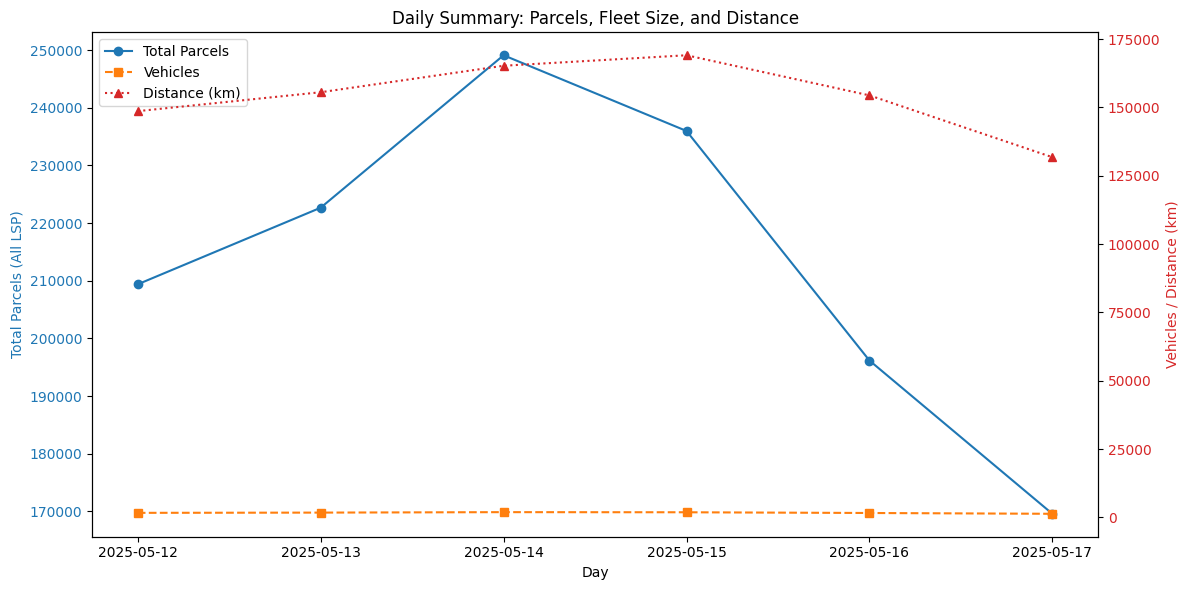

In [133]:
# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

combined['date_obj'] = pd.to_datetime(combined['basecase_date'].str.extract(r'(\d{8})')[0], format='%d%m%Y')
combined_sorted = combined.sort_values("date_obj").reset_index(drop=True)

# X-Achse
x_labels = combined_sorted['date_obj'] 

# Linke Achse: Gesamtpakete
ax1.set_xlabel('Day')
ax1.set_ylabel('Total Parcels (All LSP)', color='tab:blue')
ax1.plot(x_labels, combined_sorted['total_all_lsp'], marker='o', color='tab:blue', label='Total Parcels')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Rechte Achse: Fahrzeuge + Distanz
ax2 = ax1.twinx()
ax2.set_ylabel('Vehicles / Distance (km)', color='tab:red')
ax2.plot(x_labels, combined_sorted['num_vehicles'], marker='s', linestyle='--', color='tab:orange', label='Vehicles')
ax2.plot(x_labels, combined_sorted['total_distance_km'], marker='^', linestyle=':', color='tab:red', label='Distance (km)')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Legende
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Daily Summary: Parcels, Fleet Size, and Distance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [135]:
# 1. Referenzwerte (erster Tag)
ref_parcels = combined_sorted['total_all_lsp'].mean()
ref_distance = combined_sorted['total_distance_km'].mean()

# 2. Listen zur Speicherung
elasticities = []

for i in range(1, len(combined_sorted)):
    cur_parcels = combined_sorted['total_all_lsp'].iloc[i]
    cur_distance = combined_sorted['total_distance_km'].iloc[i]

    # Prozentuale Änderungen
    delta_parcels = (cur_parcels - ref_parcels) / ref_parcels
    delta_distance = (cur_distance - ref_distance) / ref_distance

    if delta_parcels != 0:
        elasticity = delta_distance / delta_parcels
        elasticities.append({
            "day": combined_sorted['basecase_date'].iloc[i],
            "parcel_change_%": delta_parcels * 100,
            "distance_change_%": delta_distance * 100,
            "elasticity": round(elasticity, 3)
        })

# Ausgabe als DataFrame
elasticity_df = pd.DataFrame(elasticities)
display(elasticity_df)


,day,parcel_change_%,distance_change_%,elasticity
0,basecase_13052025,4.141199,0.933347,0.225
1,basecase_14052025,16.505631,7.220688,0.437
2,basecase_15052025,10.363638,9.709596,0.937
3,basecase_16052025,-8.254102,0.185915,-0.023
4,basecase_17052025,-20.685884,-14.492794,0.701


In [137]:
print("Average Elasticity:", round(elasticity_df["elasticity"].mean(), 3))


Average Elasticity: 0.455


In [18]:
# --- Räumlicher Join: Zuordnung jeder Demand-Punkt zu einer Rasterzelle ---
joined = gpd.sjoin(parcel_input_demand_tuesday, grid_gdf[['grid_index', 'geometry']], how="inner", predicate="intersects")

# --- Aggregation: Summe aller Paketmengen je Rasterzelle ---
relevant_cols = [col for col in parcel_input_demand_tuesday.columns if any(p in col for p in ['b2b', 'b2c'])]

grouped = joined.groupby("grid_index")[relevant_cols].sum().reset_index()

# --- Grid mit gewünschten Spalten selektieren ---
grid_reduced = grid_gdf[['grid_index', 'cell_size', 'postal_cod', 'main_landu', 'geometry']]

# --- Merge der aggregierten Paketmengen auf das reduzierte Grid ---
grid_enriched = grid_reduced.merge(grouped, on="grid_index", how="left").fillna(0)

# Paketspalten auswählen
pkg_cols = [col for col in grid_enriched.columns if col.endswith("_b2b") or col.endswith("_b2c")]

# Gesamtsumme pro Zelle berechnen
grid_enriched["total_parcels"] = grid_enriched[pkg_cols].sum(axis=1)

# Ergebnis:
grid_enriched

,grid_index,cell_size,postal_cod,main_landu,geometry,ama_b2b,ama_b2c,dhl_b2b,dhl_b2c,dpd_b2b,dpd_b2c,fxt_b2b,fxt_b2c,gls_b2b,gls_b2c,her_b2b,her_b2c,ups_b2b,ups_b2c,total_parcels
0,0,1000.0,31535,different_landuse,"POLYGON ((517343.000 5812623.000, 516343.000 5...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,1000.0,31535,different_landuse,"POLYGON ((517343.000 5818623.000, 516343.000 5...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,1000.0,31535,different_landuse,"POLYGON ((517343.000 5819623.000, 516343.000 5...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,1000.0,31535,different_landuse,"POLYGON ((518343.000 5812623.000, 517343.000 5...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,1000.0,31535,residential,"POLYGON ((518343.000 5814623.000, 517343.000 5...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15912,15912,500.0,31311,different_landuse,"POLYGON ((586843.000 5813123.000, 586343.000 5...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15913,15913,500.0,31311,different_landuse,"POLYGON ((587343.000 5813123.000, 586843.000 5...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15914,15914,1000.0,31311,different_landuse,"POLYGON ((587343.000 5813623.000, 586343.000 5...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15915,15915,1000.0,31311,different_landuse,"POLYGON ((587343.000 5816623.000, 586343.000 5...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


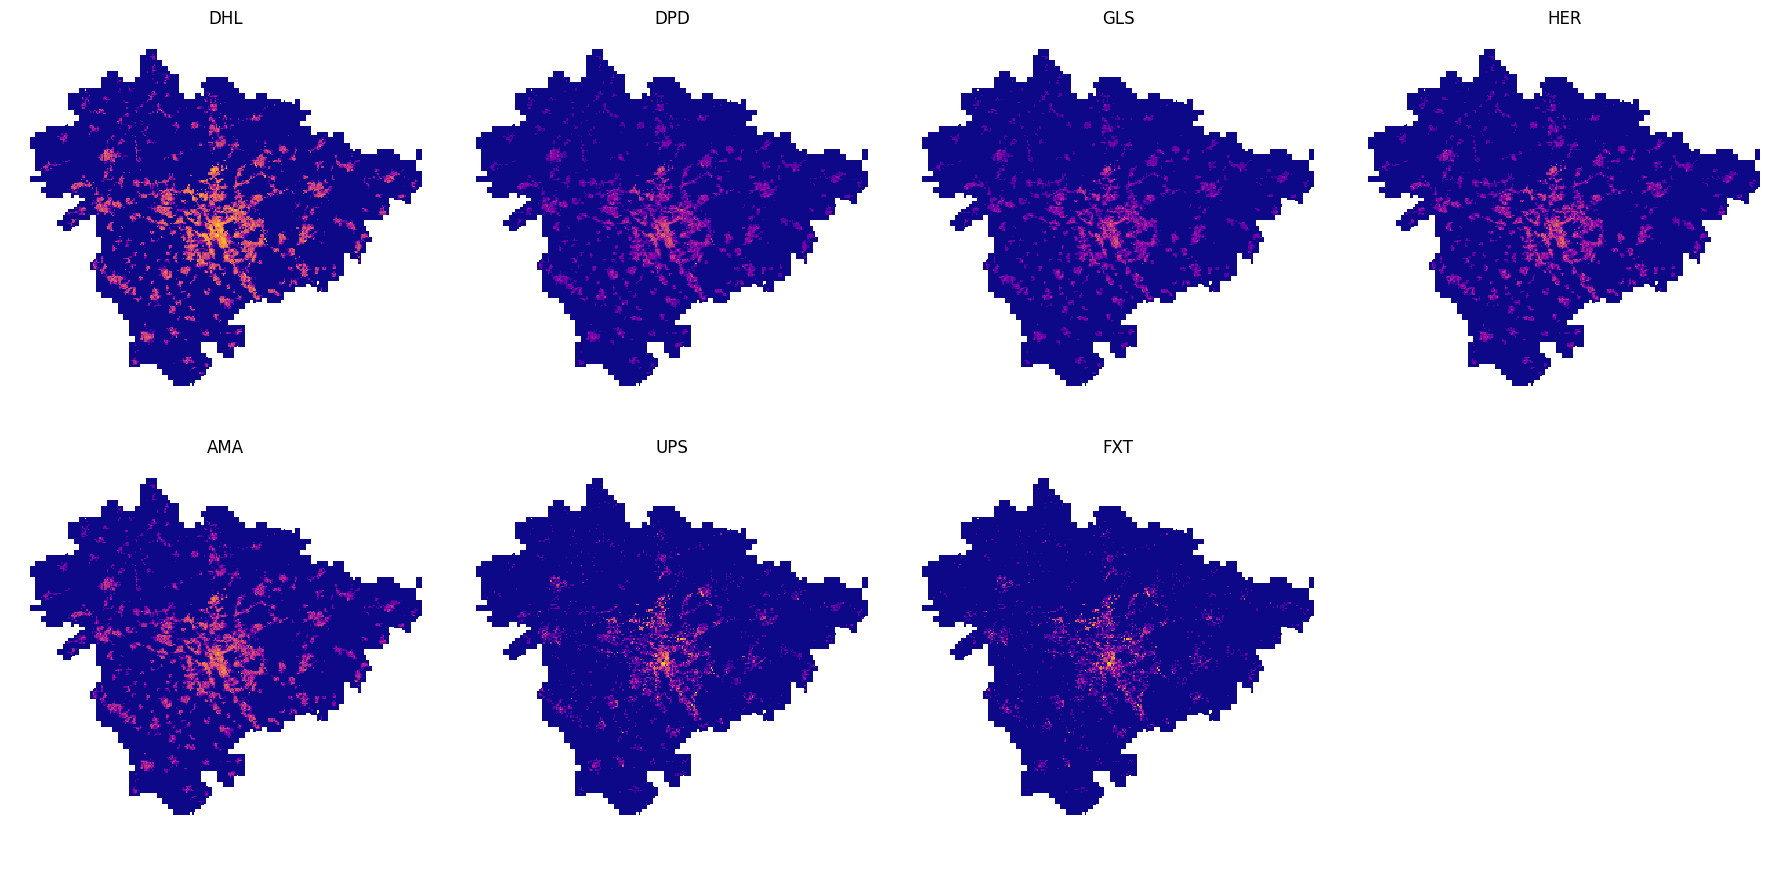

In [35]:
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

# Anbieter-Kürzel (basierend auf Spalten)
carriers = ["dhl", "dpd", "gls", "her", "ama", "ups", "fxt"]
ncols = 4
nrows = 2

# Neue log-Werte berechnen und gleichzeitig globales Maximum finden
log_columns = []
for carrier in carriers:
    colname_b2b = f"{carrier}_b2b"
    colname_b2c = f"{carrier}_b2c"
    log_col = f"{carrier}_log"
    grid_enriched[log_col] = np.log1p(grid_enriched[colname_b2b] + grid_enriched[colname_b2c])
    log_columns.append(log_col)

# Globales vmax über alle Anbieter bestimmen
global_vmax = grid_enriched[log_columns].max().max()

# Subplots vorbereiten
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 9))
axes = axes.flatten()

# Plotten mit globalem vmax
for i, carrier in enumerate(carriers):
    grid_enriched.plot(
        column=f"{carrier}_log",
        ax=axes[i],
        cmap="plasma",
        linewidth=0,
        edgecolor="none",
        vmin=0,  # Optional, log1p ist ≥ 0
        vmax=global_vmax,
    )
    axes[i].set_title(carrier.upper())
    axes[i].axis("off")

# Leeres Panel ausblenden (z. B. 8. Plot wenn carrier < 8)
for j in range(len(carriers), nrows * ncols):
    axes[j].axis("off")

plt.tight_layout()
plt.show()



In [36]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import os

# Optional: Ordner anlegen
output_folder = "carrier_maps_individual"
os.makedirs(output_folder, exist_ok=True)

# === Carrier-Setup ===
carriers = {
    "dhl": "DHL",
    "dpd": "DPD",
    "gls": "GLS",
    "her": "Hermes",
    "ama": "Amazon Logistics",
    "ups": "UPS",
    "fxt": "FedEx/TNT"
}
metrics = ["total", "b2c", "b2b"]

# === Farbskala (global) ===
log_columns = []
for c in carriers:
    for m in metrics:
        col = f"{c}_{m}_log10"
        grid_enriched[col] = np.log10(grid_enriched[f"{c}_{m}"] + 1)
        log_columns.append(col)

global_max = 10 ** grid_enriched[log_columns].max().max()
norm = colors.LogNorm(vmin=1, vmax=global_max)
cmap = "plasma"

# === Einzelkarten erzeugen ===
for carrier_key in carriers:
    for metric in metrics:
        print(f"Processing {carrier_key} - {metric}")
        colname = f"{carrier_key}_{metric}_log10"
        plot_col = 10 ** grid_enriched[colname]  # für logNorm

        grid_enriched["tmp_plot"] = plot_col

        fig, ax = plt.subplots(figsize=(6, 6))
        grid_enriched.plot(
            column="tmp_plot",
            cmap=cmap,
            norm=norm,
            linewidth=0,
            edgecolor="none",
            ax=ax
        )
        ax.set_axis_off()

        filename = f"{carrier_key}_{metric}_plasma.png"
        plt.savefig(os.path.join(output_folder, filename), dpi=300, bbox_inches="tight", pad_inches=0)
        plt.close()


Processing dhl - total
Processing dhl - b2c
Processing dhl - b2b
Processing dpd - total
Processing dpd - b2c
Processing dpd - b2b
Processing gls - total
Processing gls - b2c
Processing gls - b2b
Processing her - total
Processing her - b2c
Processing her - b2b
Processing ama - total
Processing ama - b2c
Processing ama - b2b
Processing ups - total
Processing ups - b2c
Processing ups - b2b
Processing fxt - total
Processing fxt - b2c
Processing fxt - b2b


In [110]:
# Create a dictionary linking each area type code to its description
area_type_dict = {
    1: "Metropolitan Center",
    2: "High-Density Residential Use",
    3: "Dense Mixed Use",
    4: "Residential Use",
    5: "Industrial Use",
    6: "Urbanized Periphery",
    7: "Rural with Industrial Influence",
    8: "Rural without Industrial Influence"
}

bc['main_area_description'] = bc['main_area_type'].map(area_type_dict)

from matplotlib.colors import to_hex
# Define the desired order of legend labels in English
# Create a dictionary linking each category to a color



category_color_dict = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b"
}



category_color_dict_num = {
    0: "#482878",
    1: "#3f4989",
    2: "#31688e",
    3: "#26828e",
    4: "#1f9e89",
    5: "#35b779",
    6: "#6fce58",
    7: "#b5de2b"
}



# Create a dictionary linking each category to a color
category_color = {category: i / (len(category_color_dict) - 1) for i, category in enumerate(category_color_dict)}

# Create the colormap
cmap = LinearSegmentedColormap.from_list("custom_cmap", sns.color_palette("viridis_r", len(category_color_dict))[::-1])

# Convert the colormap to a dictionary
palette_dict = {cat: to_hex(cmap(category_color[cat])) for cat in category_color_dict}


In [111]:
# Reading the GeodataFrame from a shapefile
gdf_region = gpd.read_file("input/Region Hannover.shp")

# Setting the CRS to EPSG:25832
gdf_region = gdf_region.to_crs(epsg=25832)

In [164]:
with open('input/regionclusters.pkl', 'rb') as pickle_file: # liegt in ikg-useful-share/USEfUL XT/Modul 3/Auswertung-Oskar/input/
    regionclusters = pd.read_pickle(pickle_file)

c:\Users\bienzeisler\Anaconda3\envs\matsim_geo_environment\lib\pickle.py:1718: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again; shapely 2.1 will not have this compatibility.
  setstate(state)


In [82]:
def determine_area_type(raumtyp):
    if raumtyp in [1, 2, 3]:
        return 'Urban'
    elif raumtyp in [4, 5, 6]:
        return 'Suburban'
    elif raumtyp in [7, 8]:
        return 'Rural'
    else:
        return 'unknown'
    
category_dict = {
    "1": "Metropolitan Center",
    "2": "High-Density Residential Use",
    "3": "Dense Mixed Use",
    "4": "Residential Use",
    "5": "Industrial Use",
    "6": "Urbanized Periphery",
    "7": "Rural with Industrial Influence",
    "8": "Rural without Industrial Influence"
}


# Wende die Funktion auf die Spalte raumtyp an und erstelle die neue Spalte area_type
regionclusters['area_type_agg'] = regionclusters['raumtyp'].apply(determine_area_type)
regionclusters['area_type'] = regionclusters['raumtyp'].astype(str).map(category_dict)

# Explode the multipolygons into individual polygons
regionclusters_split = regionclusters.explode(index_parts=False)

# Reset index to clean up the DataFrame
regionclusters_split.reset_index(drop=True, inplace=True)

# Display the resulting DataFrame
regionclusters_split

,name,raumtyp,area_type_agg,area_type,geometry
0,Metropoles Zentrum,1,Urban,Metropolitan Center,"POLYGON ((550245.757 5803780.217, 550498.506 5..."
1,Zentrumsnah hochverdichtete Wohnnutzung,2,Urban,High-Density Residential Use,"POLYGON ((551841.918 5799807.714, 551822.177 5..."
2,Zentrumsnah hochverdichtete Wohnnutzung,2,Urban,High-Density Residential Use,"POLYGON ((548246.648 5803396.842, 548436.729 5..."
3,Zentrumsnah hochverdichtete Wohnnutzung,2,Urban,High-Density Residential Use,"POLYGON ((551382.558 5803547.894, 551322.051 5..."
4,Zentrumsnah verdichtete Mischnutzung,3,Urban,Dense Mixed Use,"POLYGON ((550296.319 5800661.942, 550326.482 5..."
...,...,...,...,...,...
92,Umland dörflich ohne gewerblichen Einfluss,8,Rural,Rural without Industrial Influence,"POLYGON ((555171.141 5811301.777, 555348.531 5..."
93,Umland dörflich ohne gewerblichen Einfluss,8,Rural,Rural without Industrial Influence,"POLYGON ((553603.430 5818427.593, 553504.770 5..."
94,Umland dörflich ohne gewerblichen Einfluss,8,Rural,Rural without Industrial Influence,"POLYGON ((569144.127 5792666.928, 569149.889 5..."
95,Umland dörflich ohne gewerblichen Einfluss,8,Rural,Rural without Industrial Influence,"POLYGON ((567727.813 5795421.313, 567684.597 5..."


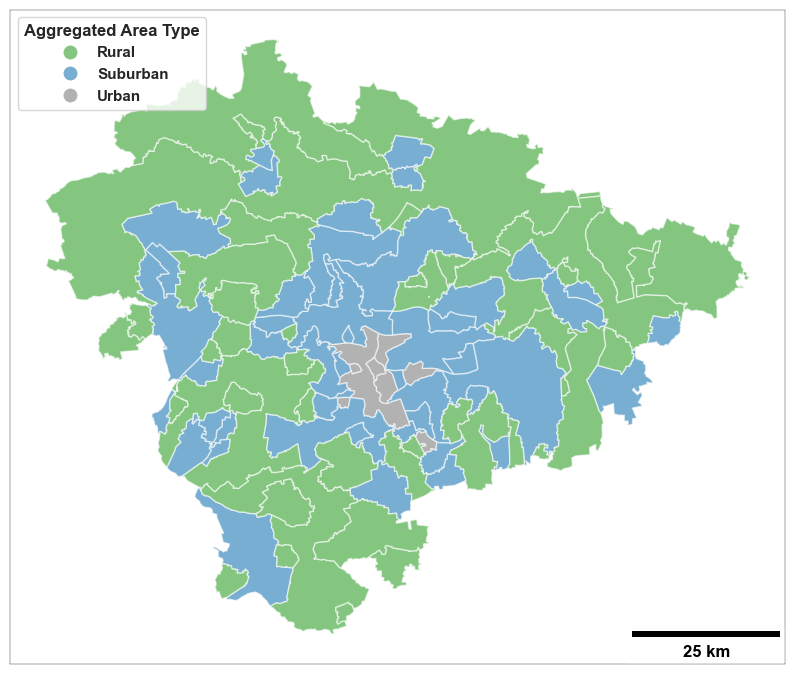

In [53]:
from matplotlib_scalebar.scalebar import ScaleBar
import geopandas as gpd
import matplotlib.pyplot as plt

# Erstelle eine Kopie des GeoDataFrames regionclusters
regionclusters_copy = regionclusters.copy()

# Projektionssystem der Kopie zu Web Mercator ändern
regionclusters_copy = regionclusters_copy.to_crs(epsg=3857)

# Erstelle eine Kopie des GeoDataFrames gdf_region
gdf_region_copy = gdf_region.copy()

# Setzen des CRS von gdf_region_copy zu Web Mercator
gdf_region_copy = gdf_region_copy.to_crs(epsg=3857)

# Plotten des GeoDataFrames mit einer Basiskarte im Hintergrund
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Farben für die verschiedenen area_types festlegen
colors = {
    'Urban': '#808080',      # Grau
    'Suburban': '#1f78b4',  # Blau
    'Rural': '#33a02c'       # Grün
}

# Plotten des GeoDataFrames mit Transparenz, benutzerdefinierten Farben und schwarzem Rahmen um die Karte
regionclusters_copy.plot(column='area_type_agg', ax=ax, legend=True, alpha=0.6,
                         legend_kwds={'title': 'Aggregated Area Type', 'loc': 'upper left'},
                         cmap=plt.matplotlib.colors.ListedColormap([colors[key] for key in sorted(colors.keys())]))


# Entfernen der Achsenbeschriftungen
ax.set_xticks([])
ax.set_yticks([])

# Hinzufügen eines Rahmens um die gesamte Karte
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.25)

# Hinzufüg#ist(scalebar)
scalebar = ScaleBar(1, units="m", location='lower right')  # 1 Pixel = 1 Meter (Web Mercator)
ax.add_artist(scalebar)

# Speichern der Abbildung als PNG
# plt.savefig("region_clusters_map_fgsv.png", format='png', bbox_inches='tight', dpi=600)

plt.show()


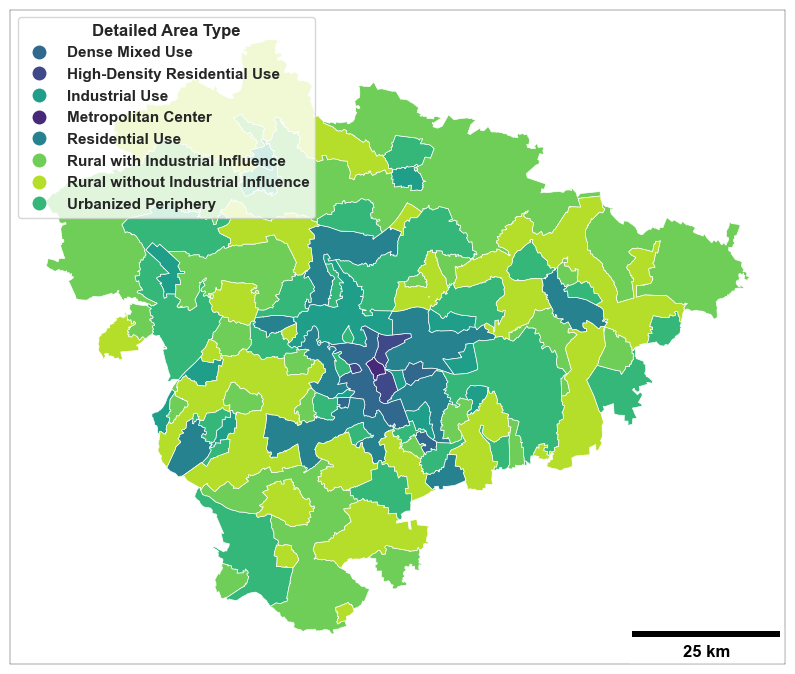

In [54]:
from matplotlib_scalebar.scalebar import ScaleBar
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Erstelle Kopien der GeoDataFrames
regionclusters_copy = regionclusters.copy().to_crs(epsg=3857)
gdf_region_copy = gdf_region.copy().to_crs(epsg=3857)

# Farbdefinition für area_type
category_color_dict = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b"
}

# Kategorien sortieren, damit Farben richtig zugeordnet werden
sorted_categories = sorted(category_color_dict.keys())
color_list = [category_color_dict[cat] for cat in sorted_categories]

# Erstelle die Farbkodierung als Categorical colormap

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

regionclusters_copy.plot(
    column='area_type',
    ax=ax,
    legend=True,
    alpha=1,
    edgecolor='white',
    linewidth=0.5,
    cmap=ListedColormap(color_list),
    legend_kwds={'title': 'Detailed Area Type', 'loc': 'upper left'}
)

# Entferne Achsenticks
ax.set_xticks([])
ax.set_yticks([])

# Rahmen um Karte
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.25)

# Optional: Maßstabsleiste hinzufügen (funktioniert nur korrekt bei metrischer Projektion)
scalebar = ScaleBar(1, units="m", location='lower right')  # 1 Pixel = 1 Meter (Web Mercator)
ax.add_artist(scalebar)

# Optional: speichern
# plt.savefig("area_type_map_fgsv.png", format='png', bbox_inches='tight', dpi=600)

plt.show()


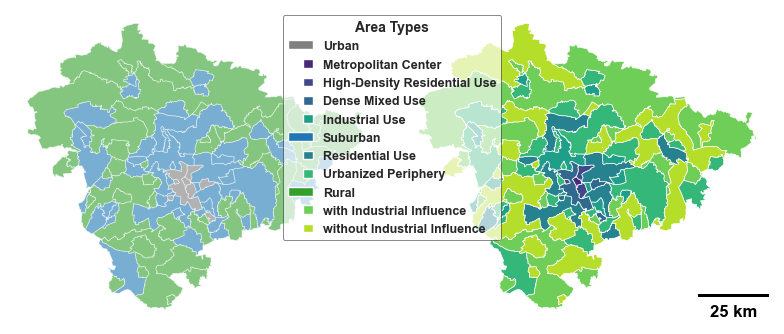

In [97]:
from matplotlib_scalebar.scalebar import ScaleBar
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

# --- Daten vorbereiten ---
regionclusters_copy = regionclusters.copy().to_crs(epsg=3857)

# --- Farbdefinitionen ---
# Aggregated
agg_colors = {
    'Urban': '#808080',
    'Suburban': '#1f78b4',
    'Rural': '#33a02c'
}
agg_color_list = [agg_colors[key] for key in sorted(agg_colors.keys())]

# Detailed
category_color_dict = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b"
}
detailed_categories = sorted(category_color_dict.keys())
detailed_color_list = [category_color_dict[cat] for cat in detailed_categories]

# Setze sortierte Kategorien
regionclusters_copy['area_type'] = regionclusters_copy['area_type'].astype('category')
regionclusters_copy['area_type'] = regionclusters_copy['area_type'].cat.set_categories(detailed_categories)

# --- Plot Setup ---
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

# --- Plot 1: Aggregated Area Types ---
regionclusters_copy.plot(
    column='area_type_agg',
    ax=axs[0],
    legend=False,
    alpha=0.6,
    edgecolor='white',
    linewidth=0.5,
    cmap=ListedColormap(agg_color_list)
)
# axs[0].set_title("Aggregated Area Types", fontsize=12)
axs[0].set_xticks([])
axs[0].set_yticks([])
# axs[0].add_artist(ScaleBar(1, units="m", location='lower right'))
# for spine in axs[0].spines.values():
#     spine.set_edgecolor('black')
#     spine.set_linewidth(0.25)

# --- Plot 2: Detailed Area Types ---
regionclusters_copy.plot(
    column='area_type',
    ax=axs[1],
    legend=False,
    alpha=1,
    edgecolor='white',
    linewidth=0.5,
    cmap=ListedColormap(detailed_color_list)
)

# # Umrisse je Aggregattyp einzeichnen
# for area_type, color in agg_colors.items():
#     dissolved = regionclusters_copy[regionclusters_copy['area_type_agg'] == area_type].dissolve()
#     dissolved.boundary.plot(
#         ax=axs[1],
#         edgecolor=color,
#         linewidth=2,
#         linestyle="-",
#         # label=f"{area_type} Outline",
#         alpha=1
#     )

# axs[1].set_title("Detailed Area Types", fontsize=12)
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[1].add_artist(ScaleBar(1, units="m", location='lower right'))
# for spine in axs[1].spines.values():
#     spine.set_edgecolor('black')
#     spine.set_linewidth(0.25)

# --- Gemeinsame Legende unterhalb beider Karten ---
# Farben
urban_color = '#808080'
suburban_color = '#1f78b4'
rural_color = '#33a02c'

# Dummy-Handels für Einrückung (z. B. 20 px breiter leerer Patch)
indent_patch = Patch(facecolor="none", edgecolor="none", linewidth=0)

# Legendeneinträge als Tuples (Einrückung + tatsächlicher Patch)
legend_elements = [
    Patch(facecolor=urban_color, edgecolor='white', label='Urban'),
    ((indent_patch, Patch(facecolor='#482878', edgecolor='white')), 'Metropolitan Center'),
    ((indent_patch, Patch(facecolor='#3f4989', edgecolor='white')), 'High-Density Residential Use'),
    ((indent_patch, Patch(facecolor='#31688e', edgecolor='white')), 'Dense Mixed Use'),
    ((indent_patch, Patch(facecolor='#1f9e89', edgecolor='white')), 'Industrial Use'),

    Patch(facecolor=suburban_color, edgecolor='white', label='Suburban'),
    ((indent_patch, Patch(facecolor='#26828e', edgecolor='white')), 'Residential Use'),
    ((indent_patch, Patch(facecolor='#35b779', edgecolor='white')), 'Urbanized Periphery'),

    Patch(facecolor=rural_color, edgecolor='white', label='Rural'),
    ((indent_patch, Patch(facecolor='#6fce58', edgecolor='white')), 'with Industrial Influence'),
    ((indent_patch, Patch(facecolor='#b5de2b', edgecolor='white')), 'without Industrial Influence'),
]


legend = fig.legend(
    handles=[h if isinstance(h, Patch) else h[0] for h in legend_elements],
    labels=[h.get_label() if isinstance(h, Patch) else h[1] for h in legend_elements],
    handler_map={tuple: HandlerTuple(ndivide=None)},
    loc='lower center',
    ncol=1,
    fontsize=9,
    title="Area Types",
    title_fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, 0.3)
)
legend.get_frame().set_alpha(0.65)
legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(0.5)

# plt.subplots_adjust(bottom=0.30)  # mehr Platz unten
for ax in axs:
    for spine in ax.spines.values():
        spine.set_visible(False)
# --- Layout finalisieren ---
plt.tight_layout()

# plt.subplots_adjust(bottom=0.15)  # Platz für Legende unten
plt.savefig("area_types_dual_map_with_outline_and_legend.pdf", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
from matplotlib_scalebar.scalebar import ScaleBar
import geopandas as gpd
import matplotlib.pyplot as plt

# Erstelle eine Kopie des GeoDataFrames regionclusters
regionclusters_copy = regionclusters.copy()

# Projektionssystem der Kopie zu Web Mercator ändern
regionclusters_copy = regionclusters_copy.to_crs(epsg=3857)

# Erstelle eine Kopie des GeoDataFrames gdf_region
gdf_region_copy = gdf_region.copy()

# Setzen des CRS von gdf_region_copy zu Web Mercator
gdf_region_copy = gdf_region_copy.to_crs(epsg=3857)

# Plotten des GeoDataFrames mit einer Basiskarte im Hintergrund
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Farben für die verschiedenen area_types festlegen
colors = {
    'Urban': '#808080',      # Grau
    'Suburban': '#1f78b4',  # Blau
    'Rural': '#33a02c'       # Grün
}

# Plotten des GeoDataFrames mit Transparenz, benutzerdefinierten Farben und schwarzem Rahmen um die Karte
regionclusters_copy.plot(column='area_type_agg', ax=ax, legend=True, alpha=0.6,
                         legend_kwds={'title': 'Area Type', 'loc': 'upper left'},
                         cmap=plt.matplotlib.colors.ListedColormap([colors[key] for key in sorted(colors.keys())]))


# Entfernen der Achsenbeschriftungen
ax.set_xticks([])
ax.set_yticks([])

# Hinzufügen eines Rahmens um die gesamte Karte
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.25)

# Hinzufüg#ist(scalebar)

# Speichern der Abbildung als PNG
# plt.savefig("region_clusters_map_fgsv.png", format='png', bbox_inches='tight', dpi=600)

plt.show()


In [88]:
sns.set()
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

In [86]:
sns.set_theme(style='white', palette='mako', rc={'figure.figsize':(7.8, 7.8)})
# sns.set()
# import matplotlib as mpl
# mpl.rcParams.update(mpl.rcParamsDefault)

mpl.rc('font', weight='bold')

# Adjust the size of ticks
mpl.rc('xtick', labelsize=8)
mpl.rc('ytick', labelsize=8)

In [163]:
unternehmen = gpd.read_file('input/companies_Total_reduced.shp')
persons_total = gpd.read_file("input/persons_total.shp")



In [167]:
import geopandas as gpd
import pandas as pd

target_crs = "EPSG:25832"

def ensure_crs(gdf, name):
    if gdf.crs != target_crs:
        print(f"⚠️ {name} hat CRS {gdf.crs}, wird umgewandelt nach {target_crs}")
        return gdf.to_crs(target_crs)
    return gdf

regionclusters = ensure_crs(regionclusters, "regionclusters")
unternehmen = ensure_crs(unternehmen, "unternehmen")
persons_total = ensure_crs(persons_total, "persons_total")
pakete = ensure_crs(parcel_input_demand_tuesday, "pakete")

# Setze Geo-Index für schnellere räumliche Abfragen
regionclusters.sindex
unternehmen.sindex
persons_total.sindex
pakete.sindex

# Räumlicher Verschnitt für Personen
persons_in_clusters = gpd.sjoin(persons_total, regionclusters, how='left', predicate='within')

# Räumlicher Verschnitt für Unternehmen
unternehmen_in_clusters = gpd.sjoin(unternehmen, regionclusters, how='left', predicate='within')

# Räumlicher Verschnitt für Pakete
pakete_in_clusters = gpd.sjoin(pakete, regionclusters, how='left', predicate='within')

# Initialisiere die Spalten für B2B und B2C Summen
# Initialisierung
pakete_in_clusters['B2B_sum'] = 0
pakete_in_clusters['B2C_sum'] = 0

# Mapping deiner echten Spalten
provider_mapping = {
    'amazon': ('ama_b2b', 'ama_b2c'),
    'dhl':    ('dhl_b2b', 'dhl_b2c'),
    'dpd':    ('dpd_b2b', 'dpd_b2c'),
    'fedex':  ('fxt_b2b', 'fxt_b2c'),
    'gls':    ('gls_b2b', 'gls_b2c'),
    'hermes': ('her_b2b', 'her_b2c'),
    'ups':    ('ups_b2b', 'ups_b2c'),
}

# Zähle direkt aus den *_b2b/_b2c-Spalten
for provider, (b2b_col, b2c_col) in provider_mapping.items():
    if b2b_col in pakete_in_clusters.columns:
        pakete_in_clusters['B2B_sum'] += pakete_in_clusters[b2b_col].fillna(0)
    if b2c_col in pakete_in_clusters.columns:
        pakete_in_clusters['B2C_sum'] += pakete_in_clusters[b2c_col].fillna(0)

# Aggregieren der Anzahl der Personen pro Raumtyp
persons_per_area_type = persons_in_clusters.groupby('area_type').size().reset_index(name='num_persons')

# Aggregieren der Anzahl der Unternehmen pro Raumtyp
unternehmen_per_area_type = unternehmen_in_clusters.groupby('area_type').size().reset_index(name='num_companies')

# Aggregieren der Anzahl der Mitarbeiter pro Raumtyp
employees_per_area_type = unternehmen_in_clusters.groupby('area_type')['employees'].sum().reset_index()

# Aggregieren der Paketmengen pro Raumtyp
pakete_per_area_type = pakete_in_clusters.groupby('area_type')['total'].sum().reset_index(name='num_pakete')

# Aggregieren der B2B und B2C Pakete pro Raumtyp
b2b_per_area_type = pakete_in_clusters.groupby('area_type')['B2B_sum'].sum().reset_index(name='num_B2B_pakete')
b2c_per_area_type = pakete_in_clusters.groupby('area_type')['B2C_sum'].sum().reset_index(name='num_B2C_pakete')

# Berechnung der Fläche pro Raumtyp in km²
regionclusters['area_km2'] = regionclusters.geometry.area / 10**6
area_per_type = regionclusters.groupby('area_type')['area_km2'].sum().reset_index()

# Zusammenführen der Ergebnisse
results = persons_per_area_type.merge(unternehmen_per_area_type, on='area_type')
results = results.merge(employees_per_area_type, on='area_type')
results = results.merge(pakete_per_area_type, on='area_type')
results = results.merge(b2b_per_area_type, on='area_type')
results = results.merge(b2c_per_area_type, on='area_type')
results = results.merge(area_per_type, on='area_type')

# Berechnung der Dichte pro km²
results['persons_density'] = results['num_persons'] / results['area_km2']
results['companies_density'] = results['num_companies'] / results['area_km2']
results['employees_density'] = results['employees'] / results['area_km2']
results['pakete_density'] = results['num_pakete'] / results['area_km2']
results['b2b_density'] = results['num_B2B_pakete'] / results['area_km2']
results['b2c_density'] = results['num_B2C_pakete'] / results['area_km2']

# Berechnung des B2B-Anteils
results['b2b_anteil'] = results['num_B2B_pakete'] / results['num_pakete']

# Zusammenfassung aller Gebiete
total_row = results.sum(numeric_only=True)
total_row['area_type'] = 'Total'
total_row['b2b_anteil'] = total_row['num_B2B_pakete'] / total_row['num_pakete']
total_row['persons_density'] = total_row['num_persons'] / total_row['area_km2']
total_row['companies_density'] = total_row['num_companies'] / total_row['area_km2']
total_row['employees_density'] = total_row['employees'] / total_row['area_km2']
total_row['pakete_density'] = total_row['num_pakete'] / total_row['area_km2']
total_row['b2b_density'] = total_row['num_B2B_pakete'] / total_row['area_km2']
total_row['b2c_density'] = total_row['num_B2C_pakete'] / total_row['area_km2']

# Umwandlung der total_row in ein DataFrame und Hinzufügen zu den Ergebnissen
total_row_df = pd.DataFrame(total_row).T

# Um sicherzustellen, dass die Spaltenreihenfolge gleich bleibt
results = pd.concat([results, total_row_df], ignore_index=True)

# Transponieren der Tabelle
results_t = results.set_index('area_type').transpose()
results_t.to_csv("result_raumtyp_diff.csv", index=True)

# Ausgabe der Ergebnisse
results_t


area_type,Dense Mixed Use,High-Density Residential Use,Industrial Use,Metropolitan Center,Residential Use,Rural with Industrial Influence,Rural without Industrial Influence,Urbanized Periphery,Total
num_persons,155529,125135,81300,11547,278087,135993,93699,269550,1150840.0
num_companies,6974,4617,5880,3967,10253,4880,1863,14496,52930.0
employees,106322,64854,103034,65340,123710,35036,14242,137725,650263.0
num_pakete,23233,21344,16860,6735,54481,25902,17380,56758,222693.0
num_B2B_pakete,5934,4966,4732,3151,10711,3903,1654,12959,48010.0
num_B2C_pakete,17299,16378,12128,3584,43770,21999,15726,43799,174683.0
area_km2,36.416843,11.968036,99.490687,2.406003,201.076208,804.115116,660.618832,479.196132,2295.287857
persons_density,4270.798563,10455.767255,817.161915,4799.245645,1382.993058,169.121308,141.835194,562.50454,501.392449
companies_density,191.504794,385.77758,59.101009,1648.792541,50.990617,6.068783,2.820083,30.250662,23.060288
employees_density,2919.583131,5418.934187,1035.614523,27157.072006,615.239372,43.570876,21.558574,287.408413,283.303464


In [8]:
results_diff = pd.read_csv("result_raumtyp_diff.csv", index_col=0)

In [156]:
# 2. Mapping raumtyp (1–8) → aggregation cluster (Urban/Suburban/Rural)
def determine_area_cluster(area_type_code):
    if area_type_code in [1, 2, 3]:
        return 'Urban'
    elif area_type_code in [4, 5, 6]:
        return 'Suburban'
    elif area_type_code in [7, 8]:
        return 'Rural'
    else:
        return None

regionclusters["area_type_agg"] = regionclusters["raumtyp"].apply(determine_area_cluster)

In [161]:
import geopandas as gpd
import pandas as pd

target_crs = "EPSG:25832"



def ensure_crs(gdf, name):
    if gdf.crs != target_crs:
        print(f"⚠️ {name} hat CRS {gdf.crs}, wird umgewandelt nach {target_crs}")
        return gdf.to_crs(target_crs).copy()
    return gdf.copy()

regionclusters = ensure_crs(regionclusters, "regionclusters")

regionclusters["area_type"] = regionclusters["area_type"].map(category_dict)    

unternehmen = ensure_crs(unternehmen, "unternehmen")
persons_total = ensure_crs(persons_total, "persons_total")
pakete = ensure_crs(parcel_input_demand_tuesday, "pakete")

# Setze Geo-Index für schnellere räumliche Abfragen
regionclusters.sindex
unternehmen.sindex
persons_total.sindex
pakete.sindex

# Räumlicher Verschnitt für Personen
persons_in_clusters = gpd.sjoin(persons_total, regionclusters, how='left', predicate='within')

# Räumlicher Verschnitt für Unternehmen
unternehmen_in_clusters = gpd.sjoin(unternehmen, regionclusters, how='left', predicate='within')

# Räumlicher Verschnitt für Pakete
pakete_in_clusters = gpd.sjoin(pakete, regionclusters, how='left', predicate='within')

# Initialisiere die Spalten für B2B und B2C Summen
# Initialisierung
pakete_in_clusters['B2B_sum'] = 0
pakete_in_clusters['B2C_sum'] = 0

# Mapping deiner echten Spalten
provider_mapping = {
    'amazon': ('ama_b2b', 'ama_b2c'),
    'dhl':    ('dhl_b2b', 'dhl_b2c'),
    'dpd':    ('dpd_b2b', 'dpd_b2c'),
    'fedex':  ('fxt_b2b', 'fxt_b2c'),
    'gls':    ('gls_b2b', 'gls_b2c'),
    'hermes': ('her_b2b', 'her_b2c'),
    'ups':    ('ups_b2b', 'ups_b2c'),
}

# Zähle direkt aus den *_b2b/_b2c-Spalten
for provider, (b2b_col, b2c_col) in provider_mapping.items():
    if b2b_col in pakete_in_clusters.columns:
        pakete_in_clusters['B2B_sum'] += pakete_in_clusters[b2b_col].fillna(0)
    if b2c_col in pakete_in_clusters.columns:
        pakete_in_clusters['B2C_sum'] += pakete_in_clusters[b2c_col].fillna(0)

# Aggregieren der Anzahl der Personen pro Raumtyp
persons_per_area_type = persons_in_clusters.groupby('area_type_agg').size().reset_index(name='num_persons')

# Aggregieren der Anzahl der Unternehmen pro Raumtyp
unternehmen_per_area_type = unternehmen_in_clusters.groupby('area_type_agg').size().reset_index(name='num_companies')

# Aggregieren der Anzahl der Mitarbeiter pro Raumtyp
employees_per_area_type = unternehmen_in_clusters.groupby('area_type_agg')['employees'].sum().reset_index()

# Aggregieren der Paketmengen pro Raumtyp
pakete_per_area_type = pakete_in_clusters.groupby('area_type_agg')['total'].sum().reset_index(name='num_pakete')

# Aggregieren der B2B und B2C Pakete pro Raumtyp
b2b_per_area_type = pakete_in_clusters.groupby('area_type_agg')['B2B_sum'].sum().reset_index(name='num_B2B_pakete')
b2c_per_area_type = pakete_in_clusters.groupby('area_type_agg')['B2C_sum'].sum().reset_index(name='num_B2C_pakete')

# Berechnung der Fläche pro Raumtyp in km²
regionclusters['area_km2'] = regionclusters.geometry.area / 10**6
area_per_type = regionclusters.groupby('area_type_agg')['area_km2'].sum().reset_index()

# Zusammenführen der Ergebnisse
results = persons_per_area_type.merge(unternehmen_per_area_type, on='area_type_agg')
results = results.merge(employees_per_area_type, on='area_type_agg')
results = results.merge(pakete_per_area_type, on='area_type_agg')
results = results.merge(b2b_per_area_type, on='area_type_agg')
results = results.merge(b2c_per_area_type, on='area_type_agg')
results = results.merge(area_per_type, on='area_type_agg')

# Berechnung der Dichte pro km²
results['persons_density'] = results['num_persons'] / results['area_km2']
results['companies_density'] = results['num_companies'] / results['area_km2']
results['employees_density'] = results['employees'] / results['area_km2']
results['pakete_density'] = results['num_pakete'] / results['area_km2']
results['b2b_density'] = results['num_B2B_pakete'] / results['area_km2']
results['b2c_density'] = results['num_B2C_pakete'] / results['area_km2']

# Berechnung des B2B-Anteils
results['b2b_anteil'] = results['num_B2B_pakete'] / results['num_pakete']

# Zusammenfassung aller Gebiete
total_row = results.sum(numeric_only=True)
total_row['area_type_agg'] = 'Total'
total_row['b2b_anteil'] = total_row['num_B2B_pakete'] / total_row['num_pakete']
total_row['persons_density'] = total_row['num_persons'] / total_row['area_km2']
total_row['companies_density'] = total_row['num_companies'] / total_row['area_km2']
total_row['employees_density'] = total_row['employees'] / total_row['area_km2']
total_row['pakete_density'] = total_row['num_pakete'] / total_row['area_km2']
total_row['b2b_density'] = total_row['num_B2B_pakete'] / total_row['area_km2']
total_row['b2c_density'] = total_row['num_B2C_pakete'] / total_row['area_km2']

# Umwandlung der total_row in ein DataFrame und Hinzufügen zu den Ergebnissen
total_row_df = pd.DataFrame(total_row).T

# Um sicherzustellen, dass die Spaltenreihenfolge gleich bleibt
results = pd.concat([results, total_row_df], ignore_index=True)

# Transponieren der Tabelle
results_t = results.set_index('area_type_agg').transpose()
results_t.to_csv("result_raumtyp_agg.csv", index=True)

# Ausgabe der Ergebnisse
results_t



area_type_agg,Rural,Suburban,Urban,Total
num_persons,229692,628937,292211,1150840.0
num_companies,6743,30629,15558,52930.0
employees,49278,364469,236516,650263.0
num_pakete,43282,128099,51312,222693.0
num_B2B_pakete,5557,28402,14051,48010.0
num_B2C_pakete,37725,99697,37261,174683.0
area_km2,1464.733948,779.763027,50.790882,2295.287857
persons_density,156.814827,806.574534,5753.217668,501.392449
companies_density,4.603566,39.279882,306.314822,23.060288
employees_density,33.64297,467.409953,4656.662583,283.303464


In [9]:
results_agg = pd.read_csv("result_raumtyp_agg.csv", index_col=0)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


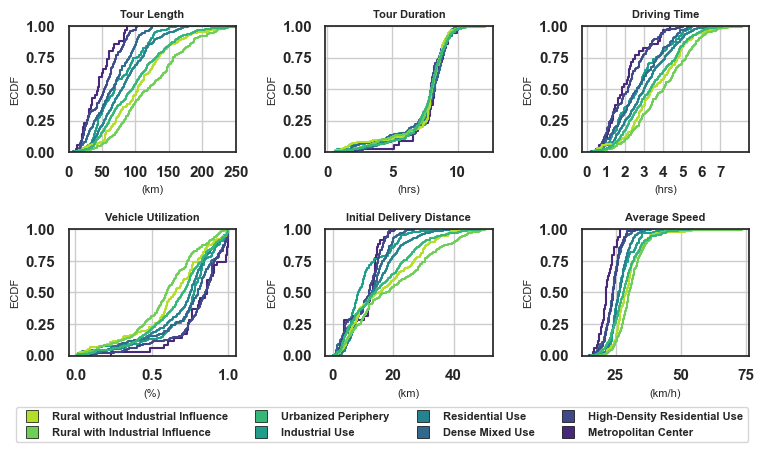

In [81]:
# Map the numbers to the area descriptions
bc['main_area_type_desc'] = bc['main_area_type'].astype(str).map(category_dict)

# Select only the necessary columns
bc_selected = bc[['Tour Length (km)', 'Tour Duration (hrs)', 'Driving Time (hrs)',
                  'Vehicle Utilization (%)', 'Initial Delivery Distance (km)', 
                  'Average Speed (km/h)','main_area_type_desc']]

sns.set_theme(style='white', palette='mako', rc={'figure.figsize':(7.8, 7.8)})

mpl.rc('font', weight='bold')

# Create a 3x2 subplot layout
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7.8, 4.25))

# Define the titles for the plots
plot_titles = ['Tour Length', 'Tour Duration', 
               'Driving Time', 'Vehicle Utilization', 
               'Initial Delivery Distance', 'Average Speed']

# Define the DataFrame and x-axis column names for each subplot
x_axes_cols = ['Tour Length (km)', 'Tour Duration (hrs)', 
               'Driving Time (hrs)', 'Vehicle Utilization (%)', 
               'Initial Delivery Distance (km)', 'Average Speed (km/h)']


# Define the x-axis labels
x_axis_labels = ['(km)', '(hrs)', 
                 '(hrs)', '(%)', 
                 '(km)', '(km/h)']

# Define the hue column name for the ECDF plot
hue_col_name = 'main_area_type_desc'

# Loop through each subplot and plot the corresponding ECDF
for i, ax in enumerate(axes.flat):
    sns.ecdfplot(data=bc_selected, x=x_axes_cols[i], ax=ax , hue=hue_col_name, palette=category_color_dict)
    ax.set_title(plot_titles[i], fontsize= 8, weight = 'bold')
    ax.set_xlabel(x_axis_labels[i], fontsize= 8)  # Adding x-axis label
    ax.set_ylabel('ECDF', fontsize= 8)
    ax.grid(True) 
    ax.legend().set_visible(False)  # Hide individual legends on each subplot
    
    # Set x-axis ticks for specific plots
    if plot_titles[i] == 'Tour Length':
        ax.set_xticks(range(0, 251, 50))
        ax.set_xlim(0, 250)
    elif plot_titles[i] == 'Driving Time':
        ax.set_xticks(range(0, 8, 1))    

    
# # Create a custom legend outside the subplots
custom_legend_labels = list(category_color_dict.keys())[::-1] # Replace with actual legend labels
# fig.legend(custom_legend_labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.035), fontsize= 8)

# Create a custom legend outside the subplots
handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=v, markeredgewidth=0.5, markeredgecolor='black', markersize=8) for v in reversed(palette_dict.values())]
fig.legend(handles, custom_legend_labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.035), fontsize= 8)

# Adjust the layout for better spacing
plt.tight_layout(rect=[0, 0.001, 1, 0.9999])  # Include space for the custom legend at the bottom

# Save the figure
plt.savefig("diff_distribution_visualization.pdf", dpi=300, bbox_inches='tight')
# Show the plots
plt.show()

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_3392\2049936387.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bc_selected, y=y_axes_cols[i], x=x_axis_col, ax=ax,
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_3392\2049936387.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bc_selected, y=y_axes_cols[i], x=x_axis_col, ax=ax,
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\bienzeisler\AppData\Loc

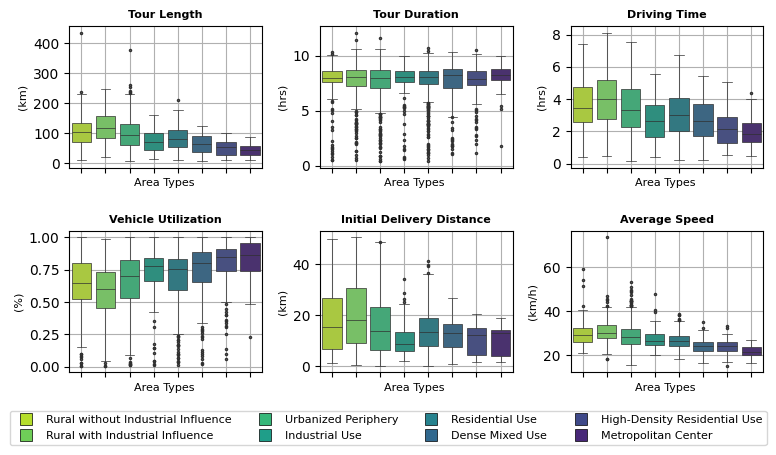

In [98]:
# Create a 2x3 subplot layout for the boxplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7.8, 4.25))

# Define a custom ordering for the x-axis
order = list(reversed(palette_dict.keys()))

# Define the titles for the plots
plot_titles = ['Tour Length', 'Tour Duration', 
               'Driving Time', 'Vehicle Utilization', 
               'Initial Delivery Distance', 'Average Speed']

# Define the DataFrame and y-axis column names for each subplot
y_axes_cols = ['Tour Length (km)', 'Tour Duration (hrs)', 
               'Driving Time (hrs)', 'Vehicle Utilization (%)', 
               'Initial Delivery Distance (km)', 'Average Speed (km/h)']

# Define the x-axis labels
y_axis_labels = ['(km)', '(hrs)', 
                 '(hrs)', '(%)', 
                 '(km)', '(km/h)']

# Define the x-axis column name for the boxplot
x_axis_col = 'main_area_type_desc'

# Loop through each subplot and plot the corresponding boxplot
for i, ax in enumerate(axes.flat):
    sns.boxplot(data=bc_selected, y=y_axes_cols[i], x=x_axis_col, ax=ax, 
                palette=palette_dict, order=order, linewidth=0.5, flierprops={"marker": "." , "markersize": 3})    
    
    ax.set_title(plot_titles[i], fontsize= 8, weight = 'bold')
    ax.set_xlabel('')  # Remove x-axis label
    ax.set_ylabel(y_axis_labels[i], fontsize= 8)  # Adding x-axis label
    ax.tick_params(axis='x', labelbottom=False)  # Remove x-axis labels
    ax.grid(True) 
    ax.legend().set_visible(False)  # Hide individual legends on each subplot
    ax.set_xlabel("Area Types \n", fontsize= 8)  # Adding x-axis label


# Create a custom legend outside the subplots
handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=v, markeredgewidth=0.5, markeredgecolor='black', markersize=8) for v in reversed(palette_dict.values())]
fig.legend(handles, custom_legend_labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.035), fontsize= 8)

# Adjust the layout for better spacing
plt.tight_layout(rect=[0, 0.001, 1, 0.9999])  # Include space for the custom legend at the bottom

plt.savefig("box_distribution_visualization.pdf", dpi=300, bbox_inches='tight')
# Show the plots
plt.show()

In [99]:
bc

,vehicle_id,Start time,End time,Tour Duration,Service Duration,Travel Duration,Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,main_area_type_desc,average_distribution,num_raumtypen,stop_distribution_abs,raumsplit_parsed_dom,dominant_area,dominant_area_desc,main_area_description,dominant_area_thresh,area_type_agg
0,freight_ups_31832_veh_cep_size_l_7_1,24682,60515,35833,12509,23324,1970-01-01 06:51:22,1970-01-01 16:48:35,1970-01-01 09:57:13,1970-01-01 03:28:29,...,Urbanized Periphery,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.6835443037974683, ...",3,"[0.0, 0.0, 0.0, 0.0, 0.0, 54.0, 24.0, 1.0]","{8: 1, 7: 24, 6: 54}",6,Urbanized Periphery,Urbanized Periphery,NaN,Suburban
1,freight_gls_30900_veh_cep_size_m_7_4,24971,68553,43582,16917,26665,1970-01-01 06:56:11,1970-01-01 19:02:33,1970-01-01 12:06:22,1970-01-01 04:41:57,...,Rural with Industrial Influence,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.12173913043478261,...",3,"[0.0, 0.0, 0.0, 0.0, 0.0, 14.0, 71.0, 30.0]","{7: 71, 6: 14, 8: 30}",7,Rural with Industrial Influence,Rural with Industrial Influence,NaN,Rural
2,freight_gls_30900_veh_cep_size_m_7_3,24971,53947,28976,8423,20553,1970-01-01 06:56:11,1970-01-01 14:59:07,1970-01-01 08:02:56,1970-01-01 02:20:23,...,Rural with Industrial Influence,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.015873015873015872...",1,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 62.0, 0.0]",{7: 63},7,Rural with Industrial Influence,Rural with Industrial Influence,7.0,Rural
3,freight_gls_30900_veh_cep_size_m_7_1,24971,61503,36532,12765,23767,1970-01-01 06:56:11,1970-01-01 17:05:03,1970-01-01 10:08:52,1970-01-01 03:32:45,...,Rural with Industrial Influence,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.02127659574468085,...",3,"[0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 86.0, 6.0]","{7: 86, 6: 2, 8: 6}",7,Rural with Industrial Influence,Rural with Industrial Influence,NaN,Rural
4,freight_gls_30900_veh_cep_size_m_7_5,25035,40431,15396,3055,12341,1970-01-01 06:57:15,1970-01-01 11:13:51,1970-01-01 04:16:36,1970-01-01 00:50:55,...,Rural with Industrial Influence,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]",1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 23.0, 0.0]",{7: 23},7,Rural with Industrial Influence,Rural with Industrial Influence,7.0,Rural
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1739,freight_amazon_30938_0_veh_cep_size_m_15_5,54051,59812,5761,726,5035,1970-01-01 15:00:51,1970-01-01 16:36:52,1970-01-01 01:36:01,1970-01-01 00:12:06,...,Urbanized Periphery,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]",1,"[0.0, 0.0, 0.0, 0.0, 0.0, 6.0, 0.0, 0.0]",{6: 6},6,Urbanized Periphery,Urbanized Periphery,6.0,Suburban
1740,freight_amazon_30625_veh_cep_size_m_15_4,54425,75067,20642,9468,11174,1970-01-01 15:07:05,1970-01-01 20:51:07,1970-01-01 05:44:02,1970-01-01 02:37:48,...,Dense Mixed Use,"[0.0, 0.0, 0.9833333333333333, 0.0166666666666...",1,"[0.0, 0.0, 59.0, 1.0, 0.0, 0.0, 0.0, 0.0]",{3: 60},3,Dense Mixed Use,Dense Mixed Use,3.0,Urban
1741,freight_amazon_30159_veh_cep_size_m_15_4,54918,73401,18483,12271,6212,1970-01-01 15:15:18,1970-01-01 20:23:21,1970-01-01 05:08:03,1970-01-01 03:24:31,...,Metropolitan Center,"[0.9705882352941176, 0.0, 0.029411764705882353...",1,"[33.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]",{1: 34},1,Metropolitan Center,Metropolitan Center,1.0,Urban
1742,freight_hermes_30163_veh_cep_size_m_14_3,55254,67695,12441,7800,4641,1970-01-01 15:20:54,1970-01-01 18:48:15,1970-01-01 03:27:21,1970-01-01 02:10:00,...,Dense Mixed Use,"[0.0, 0.15151515151515152, 0.8181818181818182,...",3,"[0.0, 5.0, 27.0, 0.0, 1.0, 0.0, 0.0, 0.0]","{3: 27, 2: 5, 5: 1}",3,Dense Mixed Use,Dense Mixed Use,NaN,Urban


In [167]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Spalten definieren
cols_perf = ['Tour Length (km)', 'Initial Delivery Distance (km)', 'Vehicle Utilization (%)', 'deliveries_per_stop', "Tour Duration (hrs)"]
cols_cost = ['vehicle_cost']

# 2. DataFrames anlegen
perf_df = bc[cols_perf].copy()
cost_df = bc[cols_cost].copy()

# 3. Normierung auf [0,1]
scaler_perf = MinMaxScaler()
perf_norm = pd.DataFrame(scaler_perf.fit_transform(perf_df), columns=cols_perf, index=bc.index)

scaler_cost = MinMaxScaler()
cost_norm = pd.DataFrame(scaler_cost.fit_transform(cost_df), columns=cols_cost, index=bc.index)

# 4. Invertiere Utilization
perf_norm['util_inv'] = 1 - perf_norm['Vehicle Utilization (%)']
perf_norm.drop(columns='Vehicle Utilization (%)', inplace=True)

# 5. Score-Berechnungen
bc['inefficiency_perf'] = perf_norm.mean(axis=1)
bc['inefficiency_cost'] = cost_norm['vehicle_cost']
bc['inefficiency_total'] = (bc['inefficiency_perf'] + bc['inefficiency_cost']) / 2

# 6. Kontrolle ausgeben
print(bc[['inefficiency_perf','inefficiency_cost','inefficiency_total']].head(10))


   inefficiency_perf  inefficiency_cost  inefficiency_total
0           0.525243           0.648175            0.586709
1           0.463274           0.800941            0.632107
2           0.473117           0.346455            0.409786
3           0.490918           0.602124            0.546521
4           0.412075           0.155594            0.283834
5           0.587203           0.618427            0.602815
6           0.456623           0.343778            0.400201
7           0.479212           0.272015            0.375613
8           0.484113           0.409501            0.446807
9           0.475282           0.231648            0.353465


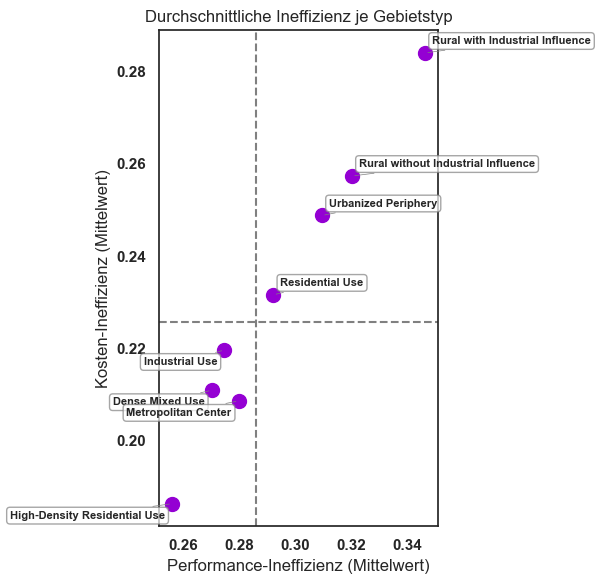

In [168]:
import matplotlib.pyplot as plt

# 1) Durchschnittswerte je Gebietstyp
avg = bc.groupby('main_area_type_desc')[['inefficiency_perf','inefficiency_cost']].mean()

# 2) Scatter-Plot der Mittelwerte
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(avg['inefficiency_perf'], avg['inefficiency_cost'], s=100, color='darkviolet')

# 3) Median-Linien als Quadranten
mp = avg['inefficiency_perf'].median()
mc = avg['inefficiency_cost'].median()
ax.axvline(mp, color='gray', linestyle='--')
ax.axhline(mc, color='gray', linestyle='--')

# 4) Beschriftung mit annotate + Background-Box + dynamischem Offset
for area, (x, y) in avg.iterrows():
    # Je nach Position leicht versetzt beschriften
    dx =  5 if x >= mp else -5
    dy =  5 if y >= mc else -5
    ax.annotate(
        area,
        xy=(x, y),
        xytext=(dx, dy),
        textcoords='offset points',
        ha='left'  if dx>0 else 'right',
        va='bottom' if dy>0 else 'top',
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', 
                  fc='white', ec='gray', alpha=0.7),
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
    )

ax.set_xlabel('Performance-Ineffizienz (Mittelwert)')
ax.set_ylabel('Kosten-Ineffizienz (Mittelwert)')
ax.set_title('Durchschnittliche Ineffizienz je Gebietstyp')
plt.tight_layout()
plt.show()


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_23080\3856596783.py:83: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from current font.
  plt.tight_layout()
c:\Users\bienzeisler\Anaconda3\envs\matsim_geo_environment\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


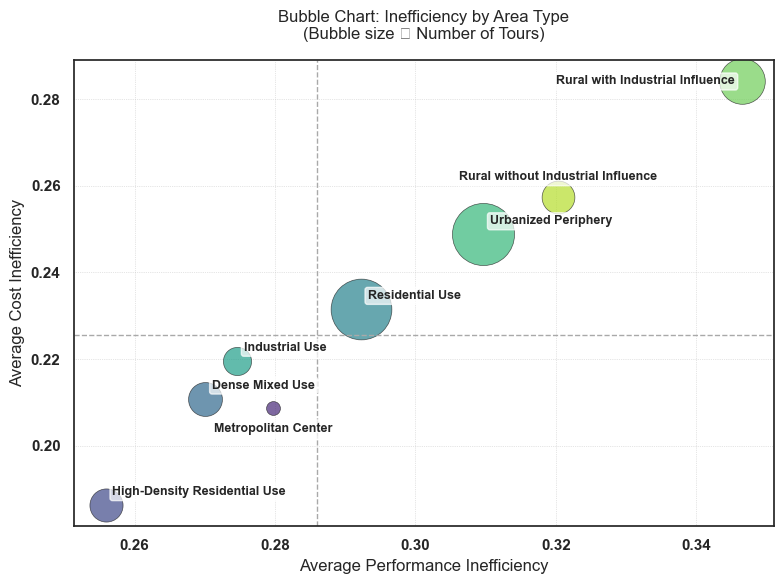

In [174]:
import matplotlib.pyplot as plt
import numpy as np

# 1) Define color mapping
category_color_dict = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b"
}

# 2) Aggregate mean metrics and counts by area type
agg = bc.groupby('main_area_type_desc').agg(
    ineff_perf=('inefficiency_perf', 'mean'),
    ineff_cost=('inefficiency_cost', 'mean'),
    tour_count=('vehicle_id', 'count')
)

# 3) Scale bubble sizes by tour_count
min_size, max_size = 100, 2000
count_norm = (agg['tour_count'] - agg['tour_count'].min()) / (agg['tour_count'].max() - agg['tour_count'].min())
sizes = min_size + count_norm * (max_size - min_size)

# 4) Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

for area in agg.index:
    x = agg.at[area, 'ineff_perf']
    y = agg.at[area, 'ineff_cost']
    color = category_color_dict.get(area, 'gray')
    size = sizes.at[area]
    ax.scatter(x, y, s=size, color=color, alpha=0.7, edgecolor='k', linewidth=0.5)

# 5) Add quadrant lines (medians)
mp = agg['ineff_perf'].median()
mc = agg['ineff_cost'].median()
ax.axvline(mp, color='darkgray', linestyle='--', linewidth=1)
ax.axhline(mc, color='darkgray', linestyle='--', linewidth=1)

# 6) Individuelle Offsets pro Gebietstyp
offsets = {
    "Rural with Industrial Influence": dict(xytext=(-5, 0), ha='right', va='center'),
    "Rural without Industrial Influence": dict(xytext=(0, 10), ha='center', va='bottom'),
    "Metropolitan Center": dict(xytext=(0, -10), ha='center', va='top'),
    # für alle anderen kannst du entweder hier defaults setzen …
}
default = dict(xytext=(5, 5), ha='left', va='bottom')

for area in agg.index:
    x = agg.at[area, 'ineff_perf']
    y = agg.at[area, 'ineff_cost']
    params = offsets.get(area, default)
    ax.annotate(
        area,
        xy=(x, y),
        xytext=params['xytext'],
        textcoords='offset points',
        ha=params['ha'],
        va=params['va'],
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7)
    )

# 7) Legend for bubble sizes (tour count)
# counts_legend = np.linspace(agg['tour_count'].min(), agg['tour_count'].max(), 3, dtype=int)
# handles = []
# for c in counts_legend:
#     s = min_size + (c - agg['tour_count'].min()) / (agg['tour_count'].max() - agg['tour_count'].min()) * (max_size - min_size)
#     handles.append(ax.scatter([], [], s=s, color='lightgray', edgecolor='k'))
#     handles[-1].set_label(f"{c} tours")
# ax.legend(handles=handles, title="Tour Count", labelspacing=1.2, loc='upper left', bbox_to_anchor=(1,1))

# 8) Styling
ax.set_xlabel('Average Performance Inefficiency')
ax.set_ylabel('Average Cost Inefficiency')
ax.set_title('Bubble Chart: Inefficiency by Area Type\n(Bubble size ∝ Number of Tours)', pad=15)
ax.grid(True, linestyle=':', linewidth=0.5)

plt.tight_layout()
plt.show()


In [182]:
bc


,vehicle_id,Start time,End time,Tour Duration,Service Duration,Travel Duration,Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,deliveries_per_stop,Hannover,Tour Duration (hrs),Driving Time (hrs),Average Speed (km/h),main_area_description,main_area_type_desc,inefficiency_perf,inefficiency_cost,inefficiency_total
0,freight_ups_31832_veh_cep_size_l_7_1,24682,60515,35833,12509,23324,1970-01-01 06:51:22,1970-01-01 16:48:35,1970-01-01 09:57:13,1970-01-01 03:28:29,...,1.278481,False,9.953611,6.478889,29.625533,Urbanized Periphery,Urbanized Periphery,0.525243,0.648175,0.586709
1,freight_gls_30900_veh_cep_size_m_7_4,24971,68553,43582,16917,26665,1970-01-01 06:56:11,1970-01-01 19:02:33,1970-01-01 12:06:22,1970-01-01 04:41:57,...,1.191304,False,12.106111,7.406944,27.742214,Rural with Industrial Influence,Rural with Industrial Influence,0.463274,0.800941,0.632107
2,freight_gls_30900_veh_cep_size_m_7_3,24971,53947,28976,8423,20553,1970-01-01 06:56:11,1970-01-01 14:59:07,1970-01-01 08:02:56,1970-01-01 02:20:23,...,1.095238,False,8.048889,5.709167,31.761419,Rural with Industrial Influence,Rural with Industrial Influence,0.473117,0.346455,0.409786
3,freight_gls_30900_veh_cep_size_m_7_1,24971,61503,36532,12765,23767,1970-01-01 06:56:11,1970-01-01 17:05:03,1970-01-01 10:08:52,1970-01-01 03:32:45,...,1.106383,False,10.147778,6.601944,31.233078,Rural with Industrial Influence,Rural with Industrial Influence,0.490918,0.602124,0.546521
4,freight_gls_30900_veh_cep_size_m_7_5,25035,40431,15396,3055,12341,1970-01-01 06:57:15,1970-01-01 11:13:51,1970-01-01 04:16:36,1970-01-01 00:50:55,...,1.086957,False,4.276667,3.428056,29.224626,Rural with Industrial Influence,Rural with Industrial Influence,0.412075,0.155594,0.283834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1739,freight_amazon_30938_0_veh_cep_size_m_15_5,54051,59812,5761,726,5035,1970-01-01 15:00:51,1970-01-01 16:36:52,1970-01-01 01:36:01,1970-01-01 00:12:06,...,1.000000,False,1.600278,1.398611,44.618473,Urbanized Periphery,Urbanized Periphery,0.337106,0.092834,0.214970
1740,freight_amazon_30625_veh_cep_size_m_15_4,54425,75067,20642,9468,11174,1970-01-01 15:07:05,1970-01-01 20:51:07,1970-01-01 05:44:02,1970-01-01 02:37:48,...,1.300000,True,5.733889,3.103889,22.857699,Dense Mixed Use,Dense Mixed Use,0.301571,0.107027,0.204299
1741,freight_amazon_30159_veh_cep_size_m_15_4,54918,73401,18483,12271,6212,1970-01-01 15:15:18,1970-01-01 20:23:21,1970-01-01 05:08:03,1970-01-01 03:24:31,...,2.941176,True,5.134167,1.725556,26.741563,Metropolitan Center,Metropolitan Center,0.248336,0.065823,0.157079
1742,freight_hermes_30163_veh_cep_size_m_14_3,55254,67695,12441,7800,4641,1970-01-01 15:20:54,1970-01-01 18:48:15,1970-01-01 03:27:21,1970-01-01 02:10:00,...,1.909091,True,3.455833,1.289167,26.708591,Dense Mixed Use,Dense Mixed Use,0.232633,0.046366,0.139500
